# Local Optimality Conditions

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 3 rewritten and 1 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

**Reference** Section 4.2 in Biegler (2010)

## Unconstrained Optimality Conditions

Recall the unconstrained optimization problem:

\begin{equation*}
\min_x f(x)
\end{equation*}

has the optimality conditions:

\begin{equation*}
\nabla f(x^*) = 0, \qquad \nabla^2 f(x^*) \succeq 0 \quad \text{( is P.S.D.)}
\end{equation*}

## Balance of Forces Interpretation

Here is a [helpful handout](../../handouts/OptimalityConditionsSummary.pdf).

Next, consider an optimization problem with only inequality constraints:

\begin{align*}
\min_x \quad & f(x) \\
\text{s.t.} \quad & g(x) \leq 0
\end{align*}

We can visualize the contours of the objective where the inequality constraint acts as a fence. The ball rolls down the gradient to find the bottom of the valley. However, the fence can only push in one direction.

![Kinematic interpretation of NLP with an inequality constraint](https://raw.githubusercontent.com/ndcbe/optimization/main/media/kinematic1.png)

Gravity pushes the ball against the fence and the fence pushes the ball back. Our intuition says that:
1. These forces need to be balanced at an equilibrium point
2. These forces are in opposite directions

Next, consider an optimization problem with both inequality and equality constraints:

\begin{align*}
\min_x \quad & f(x) \\
\text{s.t.} \quad & g(x) \leq 0 \\
 & h(x) = 0
\end{align*}

The equality constraints $h(x) = 0$ act as a rail that the solution $x$ must move along.

![Kinematic interpretation of NLP with both inequality and equality constraints](https://raw.githubusercontent.com/ndcbe/optimization/main/media/kinematic2.png)

## Karush-Kuhn-Tucker (KKT) Necessary Conditions

The constraints can only push in the direction of their gradients. The KKT (a.k.a. Lagrange) multipliers tell us how much the constraints push against the objective at the equilibrium point $x^*$ where the forces balance.

**First Order Conditions (Balance of Forces)**

\begin{equation*}
\nabla \mathcal{L}(x^*, u^*, v^*) = \nabla f(x^*) + \nabla g(x^*)^T u^* + \nabla h(x^*)^T v^* = 0
\end{equation*}

**Feasibility**

\begin{equation*}
g(x^*) \leq 0, \quad h(x^*) = 0
\end{equation*}

**Complementarity**

The inequality constraints are not always active. In other words, the fence can only push against the ball if the ball is touching the fence.

\begin{equation*}
g(x^*)^T u^* = 0
\end{equation*}

Moreover, the fence only pushes in one direction.

\begin{equation*}
u^* \geq 0
\end{equation*}

**Constraint Qualification**

We will [revisit this topic soon](../7/Constraint-Qualifications.ipynb).

**Second Order Conditions**

The Lagrange function $\mathcal{L}$ has non-negative curvature in the direction of all "reasonable" step directions $p$.

\begin{equation*}
p^T \nabla^2_{xx} \mathcal{L}(x^*, u^*, v^*) p \geq 0
\end{equation*}

In other words, for all $p \neq 0$ that satisfy the following three criteria:

1. The step $p$ maintains feasibility of the equality constraints; in other words, $p$ is along the rail/track.
2. The step $p$ maintains feasibility for all inequality constraints that are active; in other words, the fence is pushing against the ball, the ball remains on the fence.
3. The step $p$ does not cross over any inequality constraints that are weakly active; in other words, if the ball is barely touching a fence, it can either move along the fence or away from the fence. It cannot move into the fence.

Mathematically, this is:

for all $p \neq 0$:
\begin{align*}
& \nabla h_i(x^*)^T p = 0 \quad \text{(along rail/track)} \\
& \nabla g_j(x^*)^T p = 0 \quad \text{if } \xi_j = 1, g_j(x^*) = 0, u_j^* > 0 \quad \text{(along forces that are active)} \\
& \nabla g_j(x^*)^T p \leq 0 \quad \text{if } \xi_j \neq 1, g_j(x^*) = 0, u_j^* = 0 \quad \text{(forces that are inactive)} 
\end{align*}





## Kinematic Interpretation via Example

Consider the following two dimensional optimization problem:

$$
\begin{align} \min_{x_1,x_2} \quad & f(x) := x_1^2 - 4 x_1 + \frac{3}{2} x_2^2 -7x_2 + x_1 x_2 + 9 - \mathrm{ln}(x_1) - \mathrm{ln}(x_2) \\
\mathrm{s.t.} \quad & g(x) := 4 - x_1 x_2 \leq 0 \\
 & h(x) := 2 x_1 - x_2 = 0
\end{align}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

### Define Function for Visualization

In [2]:
## Objective function
def f(x):
    return (
        x[0] ** 2
        - 4 * x[0]
        + 1.5 * x[1] ** 2
        - 7 * x[1]
        + x[0] * x[1]
        + 9
        - np.log(x[0])
        - np.log(x[1])
    )


## Gradient of objective f(x)
def df(x):
    return np.array((2 * x[0] - 4 + x[1] - 1 / x[0], 3 * x[1] - 7 + x[0] - 1 / x[1]))


## Gradient of inequality constraint g(x)
def dg(x):
    return np.array((-x[1], -x[0]))


## Gradient of equality constraint h(x)
def dh(x):
    return np.array([2, -1])


## Function that plots contour of objective, solution, and optionally g(x) <= 0 and h(x) = 0
def visualize(xsln, plot_g, plot_h):
    ## Create contour plot

    n1 = 101
    n2 = 101
    x1eval = np.linspace(0.05, 10, n1)
    x2eval = np.linspace(0.05, 10, n2)

    X, Y = np.meshgrid(x1eval, x2eval)

    Z = np.zeros([n2, n1])

    for i in range(0, n1):
        for j in range(0, n2):
            Z[j, i] = f((X[j, i], Y[j, i]))

    fig, ax = plt.subplots()
    CS = ax.contour(X, Y, Z)
    ax.clabel(CS, inline=1, fontsize=10)

    ## Plot g(x) <= 0
    if plot_g:
        g_x2 = np.zeros(n1)
        for i in range(0, n1):
            # Inverted g(x) = 0 to calculate x2 explicitly from x1
            g_x2[i] = 4 / x1eval[i]

        plt.plot(x1eval, g_x2, color="blue", linestyle="-.", label=r"$g(x) \leq 0$")

    ## Plot h(x) = 0
    if plot_h:
        h_x2 = 2 * x1eval
        plt.plot(x1eval, h_x2, color="red", linestyle="--", label=r"$h(x) = 0$")

    ## Plot solution
    plt.scatter(xsln[0], xsln[1], marker="*", color="black", label=r"$x^{*}$")

    ## Adjust x and y limits
    plt.xlim([-1, 10])
    plt.ylim([-1, 10])

    ## Add legend
    plt.legend()


## Function that draws gradient of f(x) and optionally g(x) and h(x)
def draw_gradients(x, with_g, with_h):
    dh_x = dh(x)

    ## Draw gradient of f(x) [objective]
    df_x = df(x)
    plt.arrow(x[0], x[1], df_x[0], df_x[1], color="black", width=0.1)

    ## Draw gradient of g(x) [inequality]
    if with_g:
        dg_x = dg(x)
        plt.arrow(x[0], x[1], dg_x[0], dg_x[1], color="blue", width=0.1)

    ## Draw gradient of h(x) [equality]
    if with_h:
        dh_x = dh(x)
        plt.arrow(x[0], x[1], dh_x[0], dh_x[1], color="red", width=0.1)

### Define function to solve optimization problem with Pyomo

In [3]:
def solve_opt(consider_g, consider_h):

    ## Create concrete Pyomo model
    m = pyo.ConcreteModel()

    ## Declare variables with initial values
    m.x1 = pyo.Var(bounds=(0, 100), initialize=10)
    m.x2 = pyo.Var(bounds=(0, 100), initialize=10)

    ## Declare objective
    m.OBJ = pyo.Objective(
        expr=m.x1**2
        - 4 * m.x1
        + 1.5 * m.x2**2
        - 7 * m.x2
        + m.x1 * m.x2
        + 9
        - pyo.log(m.x1)
        - pyo.log(m.x2),
        sense=pyo.minimize,
    )

    if consider_g:
        ## Add inequality constraint
        m.con1 = pyo.Constraint(expr=4 - m.x1 * m.x2 <= 0)

    if consider_h:
        ## Add equality constraint
        m.con2 = pyo.Constraint(expr=2 * m.x1 - m.x2 == 0)

    ## Specify IPOPT as solver
    solver = pyo.SolverFactory("ipopt")

    ## Solve the model
    results = solver.solve(m, tee=True)
    assert pyo.check_optimal_termination(results), (
        f"Solve failed: status={results.solver.status}, "
        f"termination={results.solver.termination_condition}"
    )

    ## Return the solution
    return [pyo.value(m.x1), pyo.value(m.x2)]

### The whole picture, in three takes

![KKT geometry in three takes: the unconstrained minimum, then with $g(x)\le 0$ added, then with $h(x)=0$ as well; the gradients at $x^*$ are drawn and labelled in the last two panels.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/kkt-geometry.png)

Rendered from `figures/plots/kkt-geometry.py`, and the **same image printed in the
course pack** so the handout and the website cannot drift apart. It solves the three
problems with `scipy` rather than Pyomo, purely so that regenerating the figure does not
need a solver binary; the solutions agree with the Pyomo ones below to six figures.

Now build the same three takes yourself.


### Take 1: Unconstrained

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

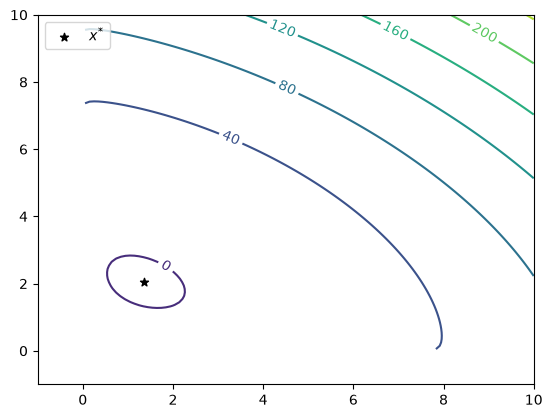

In [4]:
# Solve optimization problem
xsln = solve_opt(False, False)

# Create contour plot
visualize(xsln, False, False)

plt.show()

### Take 2. With $g(x) \leq 0$

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

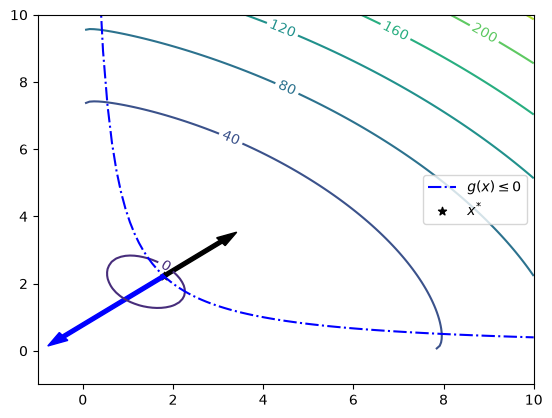

In [5]:
# Solve optimization problem
xsln = solve_opt(True, False)

# Create contour plot
visualize(xsln, True, False)

# Draw gradient
draw_gradients(xsln, True, False)

plt.show()

### Take 3. With $g(x) \leq 0$ and $h(x) = 0$

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

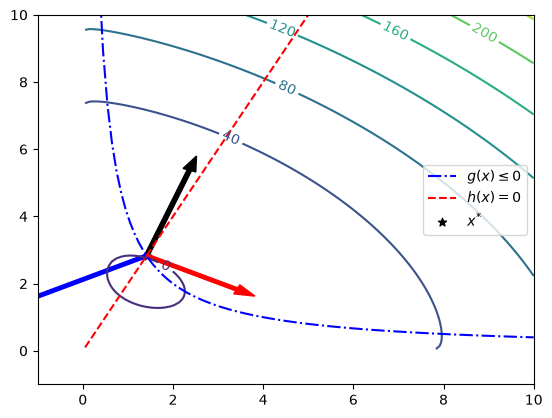

In [6]:
# Solve optimization problem
xsln = solve_opt(True, True)

# Create contour plot
visualize(xsln, True, True)

# Draw gradient
draw_gradients(xsln, True, True)

plt.show()

### Discussion

Why are the gradient vectors not the same length? I thought the forces were balanced...

### Analysis without Constraints

![picture](https://raw.githubusercontent.com/ndcbe/optimization/main/media/unconstrained_analysis.png)

### Analysis with Constraints

![picture](https://raw.githubusercontent.com/ndcbe/optimization/main/media/constrained_analysis.png)